# Trabajo: IA y Aprendizaje Automático — Análisis y Modelado de Series Temporales

Autores: Jorge Cueva, Mateo Barzallo, Karen Quito  

---



In [7]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset y parseo de fechas
df = pd.read_csv("inventario.csv", parse_dates=["created_at"])
print("Dimensiones del dataset:", df.shape)
df.head(3)

Dimensiones del dataset: (9520, 28)


,id,created_at,product_id,product_name,product_sku,category,supplier_id,supplier_name,warehouse_location,shelf_location,...,unit_cost,total_value,stock_status,last_order_date,last_stock_count_date,batch_number,last_updated_at,notes,is_active,created_by_id
0,7665e68e-4b5e-4daf-886f-d40938453310,2024-07-01,PROD-001,Laptop Dell Inspiron 15,LAP-DELL-001,2,PROV-001,TechDistributor SA,Warehouse C,A2,...,650.0,6500.0,3,2024-06-13,2024-06-24,BATCH-202407-9935,2024-07-01 00:05:00,NaN,True,c7f46930-ec36-46ca-baa9-17182396dfb3
1,fbe661d8-17de-42cb-8b97-c86d6526efd1,2024-07-02,PROD-001,Laptop Dell Inspiron 15,LAP-DELL-001,2,PROV-001,TechDistributor SA,Warehouse C,A2,...,650.0,6500.0,3,2024-06-13,2024-06-25,BATCH-202407-9935,2024-07-02 01:16:00,NaN,True,a812d453-f36a-4b5f-8b34-df4d8fffebf7
2,06a44e68-d0f5-4df3-88b4-e6c57d284e9f,2024-07-03,PROD-001,Laptop Dell Inspiron 15,LAP-DELL-001,2,PROV-001,TechDistributor SA,Warehouse C,A2,...,650.0,6500.0,3,2024-06-13,2024-06-26,BATCH-202407-9935,2024-07-03 00:30:00,NaN,True,1bd4b2b9-1149-46b6-843f-3a4b8a1b0d4d


## Analisis Exploratorio de Datos (EDA)
En esta sección se realiza un análisis visual y estadístico del comportamiento de las variables clave del inventario,
con el objetivo de comprender la dinámica del stock y sus relaciones antes del modelado.


In [8]:
df["mes"] = df["created_at"].dt.month_name()
df["anio_mes"] = df["created_at"].dt.to_period("M").astype(str)


In [9]:
# -----------------------------------------------------------
# 🔹 AGRUPACIÓN MENSUAL
# -----------------------------------------------------------
# Promedio mensual del quantity_available
ventas_mensuales = (
    df.groupby(["anio_mes", "category"])["quantity_available"]
      .mean()
      .reset_index()
)

# Ordenar meses cronológicamente
ventas_mensuales["anio_mes"] = pd.to_datetime(ventas_mensuales["anio_mes"])
ventas_mensuales = ventas_mensuales.sort_values("anio_mes")


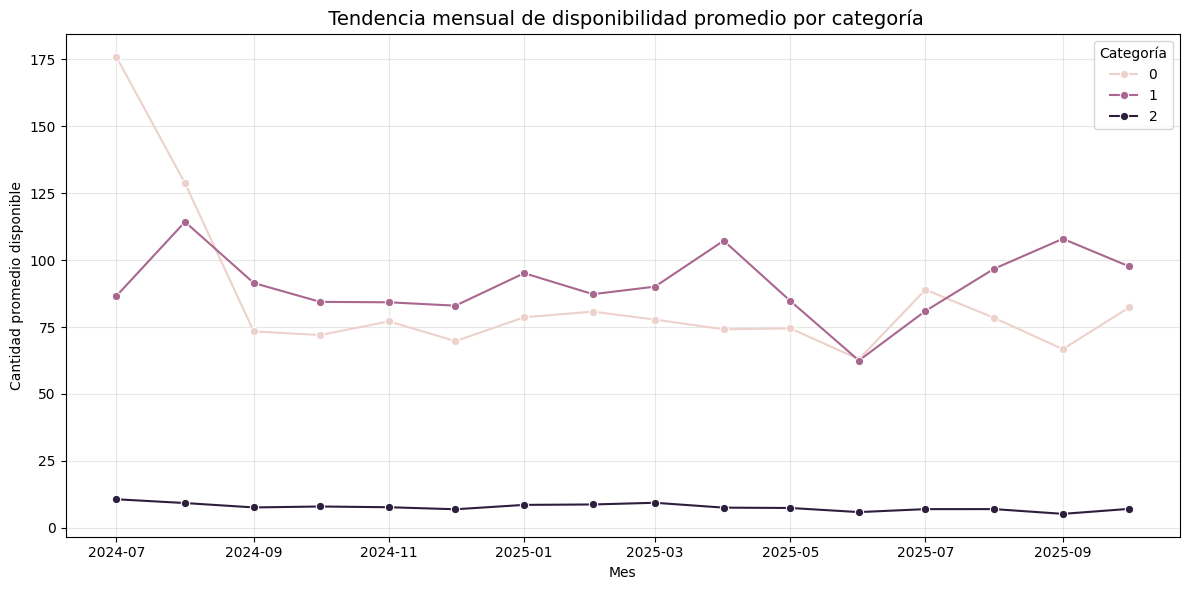

In [10]:
# -----------------------------------------------------------
# 🔹 GRAFICO 1 - TENDENCIA MENSUAL POR CATEGORÍA
# -----------------------------------------------------------
plt.figure(figsize=(12,6))
sns.lineplot(
    data=ventas_mensuales,
    x="anio_mes",
    y="quantity_available",
    hue="category",
    marker="o"
)
plt.title(" Tendencia mensual de disponibilidad promedio por categoría", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Cantidad promedio disponible")
plt.grid(True, alpha=0.3)
plt.legend(title="Categoría")
plt.tight_layout()
plt.show()



####  Distribución de la cantidad disponible por categoría

La figura correspondiente al boxplot muestra cómo se distribuye la cantidad disponible de inventario entre las categorías Alta gama, Accesorios y Media.
Se observa que la categoría Alta gama presenta una disponibilidad baja y concentrada en un rango reducido, lo que evidencia productos de carácter exclusivo y con menor rotación. Además, algunos valores atípicos reflejan excepciones en las que el stock supera el promedio habitual.

En contraste, la categoría Accesorios exhibe una amplia dispersión de valores, acompañada de múltiples outliers. Esto indica una variabilidad significativa en el control de inventario, posiblemente derivada de la alta demanda o reposiciones no uniformes.

Por su parte, la categoría Media mantiene una distribución más equilibrada y consistente, con niveles promedio de entre 60 y 120 unidades. La ausencia de valores extremos relevantes sugiere una gestión más estable y eficiente del stock.

/tmp/ipykernel_32971/1011176324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="quantity_available", palette="Set2")


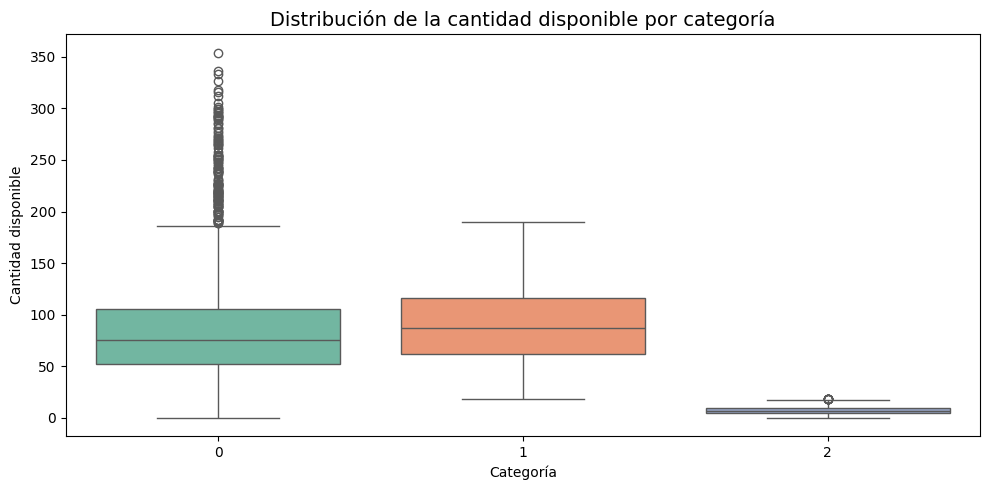

In [11]:
# -----------------------------------------------------------
# 🔹 GRAFICO 2 - DISTRIBUCIÓN DE STOCK POR CATEGORÍA
# -----------------------------------------------------------
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="category", y="quantity_available", palette="Set2")
plt.title("Distribución de la cantidad disponible por categoría", fontsize=14)
plt.ylabel("Cantidad disponible")
plt.xlabel("Categoría")
plt.tight_layout()
plt.show()


#### Tendencia mensual de disponibilidad promedio por categoría

El gráfico de tendencia temporal evidencia la evolución del stock promedio mensual por categoría.
Durante los primeros meses (mediados de 2024), la categoría Accesorios mostraba un nivel elevado de inventario, superando las 170 unidades promedio. No obstante, a partir de septiembre de 2024 se aprecia una reducción sostenida, hasta estabilizarse entre 70 y 80 unidades, lo cual podría indicar un ajuste deliberado de abastecimiento tras un periodo de sobrestock.

La categoría Media mantiene una tendencia más estable a lo largo del tiempo, con valores que oscilan entre 80 y 110 unidades, representando una gestión constante y predecible de la demanda.

Por último, la categoría Alta gama conserva valores bajos de disponibilidad (por debajo de las 10 unidades promedio), acorde con productos de alta especialización o rotación lenta.

/tmp/ipykernel_32971/3262062527.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


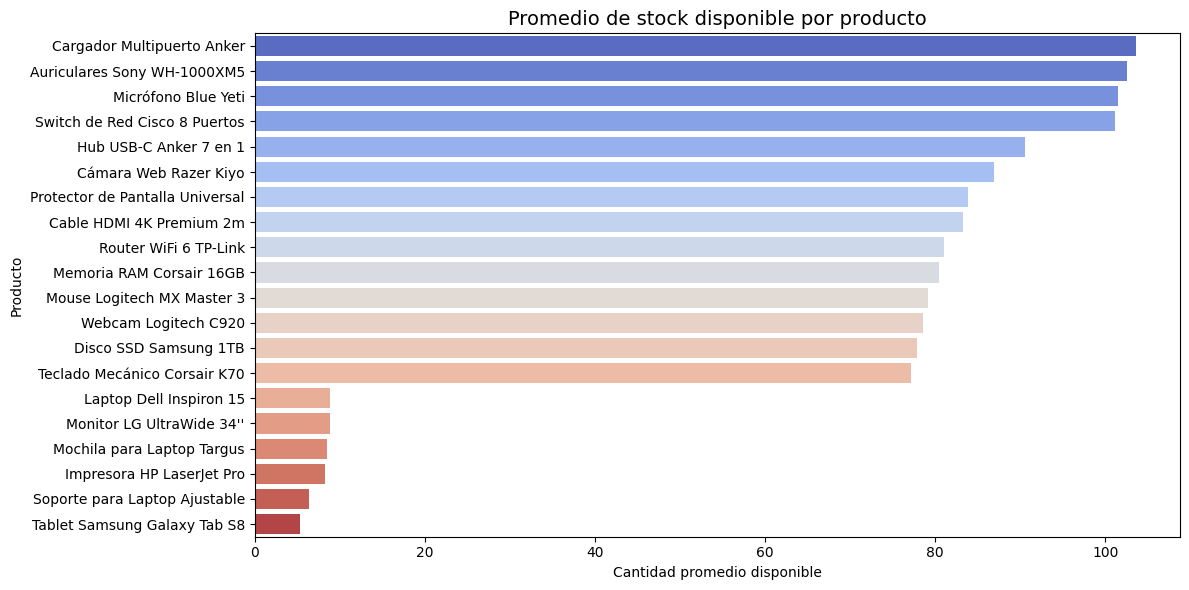

In [12]:
# -----------------------------------------------------------
# 🔹 GRAFICO 3 - PROMEDIO DE STOCK POR PRODUCTO
# -----------------------------------------------------------
promedio_stock = (
    df.groupby("product_name")["quantity_available"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=promedio_stock,
    x="quantity_available",
    y="product_name",
    hue=None,
    palette="coolwarm"
)
plt.title("Promedio de stock disponible por producto", fontsize=14)
plt.xlabel("Cantidad promedio disponible")
plt.ylabel("Producto")
plt.tight_layout()
plt.show()

#### Promedio de stock disponible por producto

El análisis del promedio de stock por producto permite identificar aquellos artículos con mayor nivel de disponibilidad en el inventario.
Entre los productos con mayor promedio se encuentran el Cargador MultiPuerto Anker, los Auriculares Sony WH-1000XM5, el Micrófono Blue Yeti, el Switch de Red Cisco 8 Puertos y el Hub USB-C Anker 7 en 1, todos superando las 90 unidades promedio. Este comportamiento refleja una estrategia de reposición constante en artículos de alta rotación o demanda recurrente.

Por el contrario, los productos como la Tablet Samsung Galaxy Tab S8, el Soporte para Laptop Ajustable, la Impresora HP LaserJet Pro y la Mochila para Laptop Targus presentan promedios inferiores a las 20 unidades, lo cual puede estar relacionado con su naturaleza de baja demanda o elevado costo unitario.

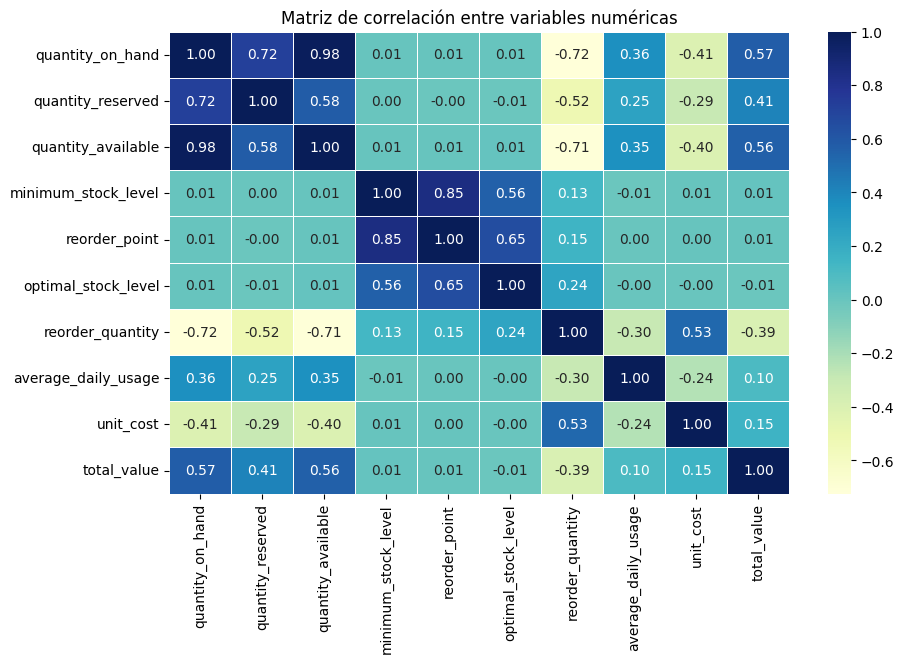

In [7]:
plt.figure(figsize=(10,6))
corr = df[[
    "quantity_on_hand","quantity_reserved","quantity_available",
    "minimum_stock_level","reorder_point","optimal_stock_level",
    "reorder_quantity","average_daily_usage","unit_cost","total_value"
]].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

Se observan correlaciones fuertes entre:
 - `quantity_on_hand` y `quantity_available` (r ≈ 0.97)
 - `minimum_stock_level`, `reorder_point` y `optimal_stock_level` (r > 0.8)
 - `reorder_quantity` y `quantity_on_hand` (r ≈ -0.5)
 
Esto refleja consistencia entre las políticas de stock y el comportamiento del inventario. 



## Preparación de Datos




Se observa que el dataset cuenta con **27 columnas**.

La **variable objetivo** será:  
`quantity_available` (stock disponible)

Además, contamos con más de **9 000 registros**, los cuales representan observaciones diarias de inventario para distintos productos.


### Variables más relevantes para el análisis

- `created_at`: se utilizará para observar el flujo temporal de las ventas y actualizaciones de inventario.  
- `product_id`: permite identificar el producto que se analizará dentro de las series.
- `quantity_reserved`: muestra las unidades reservadas que no están disponibles para la venta inmediata.  
- `quantity_on_hand`: representa la cantidad total de unidades disponibles en inventario.  
- `reorder_point` y `optimal_stock_level`: indican los niveles críticos y óptimos de stock.  
- `average_daily_usage`: refleja el consumo promedio diario de cada producto.  
- `stock_status`: codifica el estado actual del producto (agotado, bajo, normal, etc.).  
- `quantity_available`: será la variable que buscaremos modelar y predecir con base en las demás.  

Las demás columnas (como `supplier_name`, `warehouse_location` o `shelf_location`) son útiles para trazabilidad, pero en el contexto del análisis de **tendencias y series temporales** podrían introducir **ruido o redundancia**.


## Rol: Feature Engineer
 
En esta parte se generan variables temporales derivadas de `created_at` para capturar patrones estacionales y tendencias en el inventario, facilitando el modelado predictivo.


#### Creación de variables temporales


In [13]:
df["anio"] = df["created_at"].dt.year # variable año
df["mes"] = df["created_at"].dt.month # variable mes
df["dia"] = df["created_at"].dt.day # variable día
df["dia_semana"] = df["created_at"].dt.dayofweek # variable día de la semana
df["nombre_dia"] = df["created_at"].dt.day_name() # variable nombre del día
df["fin_de_semana"] = df["dia_semana"] >= 5 # variable fin de semana
df["semana_anio"] = df["created_at"].dt.isocalendar().week # variable semana del año


In [16]:
df['average_daily_usage'] = df['average_daily_usage'].fillna(0)



#### Selección de variables clave

Se seleccionan las variables más importantes para el modelado y se asegura el orden temporal correcto por producto.

Esto es CRUCIAL para que las secuencias futuras se generen correctamente.


In [17]:
df = df.sort_values(["product_id", "created_at"]).reset_index(drop=True)

df_final = df[[
    "product_id", "created_at", "category", "quantity_available",
    "quantity_on_hand", "quantity_reserved", "reorder_point", 
    "optimal_stock_level", "average_daily_usage", "stock_status",
    "anio", "mes", "dia_semana", "fin_de_semana"
]]

print(df_final.shape)
df_final.head(3)

(9520, 14)


,product_id,created_at,category,quantity_available,quantity_on_hand,quantity_reserved,reorder_point,optimal_stock_level,average_daily_usage,stock_status,anio,mes,dia_semana,fin_de_semana
0,PROD-001,2024-07-01,2,9,10,1,38,60,0.0,3,2024,7,0,False
1,PROD-001,2024-07-02,2,9,10,1,30,40,0.0,3,2024,7,1,False
2,PROD-001,2024-07-03,2,7,10,3,20,27,0.0,3,2024,7,2,False


In [18]:
df_final.to_csv("dataset_preparado.csv", index=False)